# BiHDTrans adaptado a Clasificación Molecular (BBBP)
## Implementación fiel a Zhang et al., 2025 (arXiv:2509.24425)

Este notebook implementa BiHDTrans sobre el mismo problema de la Semana 4.

**Referencia:** Zhang, J. et al. — *BiHDTrans: Binary Hyperdimensional Transformer for Efficient Multivariate Time Series Classification* — arXiv:2509.24425 (2025)  
**Dataset:** BBBP | **D = 10.000** | **N_HEADS = 4**


## 0. Dependencias

In [1]:
import importlib, subprocess, sys
for pkg in ["rdkit"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import warnings
warnings.filterwarnings("ignore")
print("✓ Dependencias listas")


✓ Dependencias listas


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request, io

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

SEED     = 42
D        = 10_000
N_HEADS  = 4
N_LEVELS = 100
ECFP_NBITS = 2048
np.random.seed(SEED)

print(f"D={D:,} | N_HEADS={N_HEADS} | binario end-to-end (BiHDTrans)")


D=10,000 | N_HEADS=4 | binario end-to-end (BiHDTrans)


## 1. Datos y Encoding Base (idéntico a Semana 4)

In [3]:
URL = ("https://raw.githubusercontent.com/GLambard/Molecules_Dataset_Collection"
       "/master/originals/BBBP.csv")
with urllib.request.urlopen(URL) as r:
    df = pd.read_csv(io.StringIO(r.read().decode()))

df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df = df[df["mol"].notna()].reset_index(drop=True)

df["MW"]   = df["mol"].apply(Descriptors.MolWt)
df["LogP"] = df["mol"].apply(Descriptors.MolLogP)
df["MR"]   = df["mol"].apply(Descriptors.MolMR)
scaler = MinMaxScaler()
df[["MW_n","LogP_n","MR_n"]] = scaler.fit_transform(df[["MW","LogP","MR"]])

print(f"Moléculas: {len(df)} | Clases: {df['p_np'].value_counts().to_dict()}")


[11:13:47] Explicit valence for atom # 1 N, 4, is greater than permitted
[11:13:47] WARNING: not removing hydrogen atom without neighbors
[11:13:47] Explicit valence for atom # 6 N, 4, is greater than permitted
[11:13:47] WARNING: not removing hydrogen atom without neighbors
[11:13:47] WARNING: not removing hydrogen atom without neighbors
[11:13:47] WARNING: not removing hydrogen atom without neighbors
[11:13:47] WARNING: not removing hydrogen atom without neighbors
[11:13:47] WARNING: not removing hydrogen atom without neighbors
[11:13:47] WARNING: not removing hydrogen atom without neighbors
[11:13:47] Explicit valence for atom # 6 N, 4, is greater than permitted
[11:13:47] WARNING: not removing hydrogen atom without neighbors
[11:13:47] WARNING: not removing hydrogen atom without neighbors
[11:13:47] WARNING: not removing hydrogen atom without neighbors
[11:13:47] WARNING: not removing hydrogen atom without neighbors
[11:13:47] Explicit valence for atom # 11 N, 4, is greater than pe

Moléculas: 2039 | Clases: {1: 1560, 0: 479}


In [4]:
# ── h_struct via ECFP4 + proyección bipolar ───────────────────────────────────
rng_proj = np.random.default_rng(SEED)
proj_ecfp = rng_proj.choice([-1,1], size=(ECFP_NBITS, D)).astype(np.float32)

def mol_to_hstruct(mol):
    fp = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=ECFP_NBITS), dtype=np.float32)
    hv = np.sign(fp @ proj_ecfp); hv[hv==0]=1; return hv

# ── h_prop via Level-HVs ─────────────────────────────────────────────────────
rng_lv = np.random.default_rng(SEED)
base = rng_lv.choice([-1,1], size=D).astype(np.int8)
level_hvs_list = [base.copy()]
for _ in range(N_LEVELS - 1):
    v = level_hvs_list[-1].copy()
    v[rng_lv.choice(D, size=D//N_LEVELS, replace=False)] *= -1
    level_hvs_list.append(v)
level_hvs = np.array(level_hvs_list, dtype=np.float32)

def mol_to_hprop(row):
    def enc(v): return level_hvs[min(int(v*N_LEVELS), N_LEVELS-1)]
    hvs = np.stack([enc(row["MW_n"]), enc(row["LogP_n"]), enc(row["MR_n"])])
    out = np.sign(hvs.sum(axis=0)); out[out==0]=1; return out

print("Codificando h_struct y h_prop...")
h_struct_all = np.array([mol_to_hstruct(m) for m in df["mol"]], dtype=np.float32)
h_prop_all   = np.array([mol_to_hprop(row) for _, row in df.iterrows()], dtype=np.float32)

# Secuencia de entrada: (N, L=2, D)
H_e_all = np.stack([h_struct_all, h_prop_all], axis=1)
assert H_e_all.shape == (len(df), 2, D)
print(f"✓ Secuencia H_e: {H_e_all.shape}  — tokens: [h_struct, h_prop]")


Codificando h_struct y h_prop...


[11:13:49] DEPRECATION WARNING: please use MorganGenerator
[11:13:49] DEPRECATION WARNING: please use MorganGenerator
[11:13:49] DEPRECATION WARNING: please use MorganGenerator
[11:13:49] DEPRECATION WARNING: please use MorganGenerator
[11:13:49] DEPRECATION WARNING: please use MorganGenerator
[11:13:49] DEPRECATION WARNING: please use MorganGenerator
[11:13:49] DEPRECATION WARNING: please use MorganGenerator
[11:13:49] DEPRECATION WARNING: please use MorganGenerator
[11:13:49] DEPRECATION WARNING: please use MorganGenerator
[11:13:49] DEPRECATION WARNING: please use MorganGenerator
[11:13:49] DEPRECATION WARNING: please use MorganGenerator
[11:13:49] DEPRECATION WARNING: please use MorganGenerator
[11:13:49] DEPRECATION WARNING: please use MorganGenerator
[11:13:49] DEPRECATION WARNING: please use MorganGenerator
[11:13:49] DEPRECATION WARNING: please use MorganGenerator
[11:13:49] DEPRECATION WARNING: please use MorganGenerator
[11:13:49] DEPRECATION WARNING: please use MorganGenerat

✓ Secuencia H_e: (2039, 2, 10000)  — tokens: [h_struct, h_prop]


## 2. HD Transformer — Implementación fiel a BiHDTrans

### Las tres diferencias clave respecto al notebook anterior

**1. Q/K/V via Binding (no matmul)**

En BiHDTrans el equivalente de la proyección lineal Q/K/V de un Transformer clásico es el **binding elemento a elemento** entre el hipervector de entrada y un hipervector binario entrenable BV:

$$\mathcal{H}_q = \mathcal{H}_e \odot \mathcal{BV}_q, \quad \mathcal{H}_k = \mathcal{H}_e \odot \mathcal{BV}_k, \quad \mathcal{H}_v = \mathcal{H}_e \odot \mathcal{BV}_v$$

Esto es válido porque el binding (multiplicación elemento a elemento de vectores del mismo tamaño) equivale a multiplicar por una **matriz diagonal** — un caso particular de capa lineal.

**2. Scores binarizados (no softmax)**

$$B_a = \text{bool}(\mathcal{H}_q \cdot \mathcal{H}_k^\top), \quad B_a \in \{0, 1\}^{L \times L}$$

El producto punto entero se binariza con umbral 0 (positivo → 1, no-positivo → 0). No hay división por √d ni softmax. Esto produce una **máscara de selección** discreta.

**3. Selective Bundling (no suma ponderada real)**

$$\mathcal{H}_a^t = \text{sign}\!\left(\sum_{i=1}^L \mathcal{H}_v^i \cdot b_{t,i}\right)$$

Para cada token de query $t$, se suman solo los V's donde $b_{t,i}=1$ y se aplica signo. El resultado es binario.


In [5]:
def binarize(x: np.ndarray) -> np.ndarray:
    """Binariza a {-1, +1} con STE-compatible (preserva dtype float para backprop)."""
    s = np.sign(x).astype(np.float32)
    s[s == 0] = 1.0
    return s


def bihdtrans_forward(
    H_e: np.ndarray,           # (N, L, D) — secuencia de hipervectores binarios
    BVq_d: list, BVk_d: list,  # listas de N_HEADS arrays (D,) — parámetros densos
    BVv_d: list, BVa_d: list,
    C_d: np.ndarray,           # (K, D) — prototipos densos (LeHDC)
    n_heads: int, D: int
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Forward pass completo de BiHDTrans.

    Retorna
    -------
    logits   : (N, K)  — similitud coseno con prototipos
    H_out    : (N, D)  — hipervector final por molécula
    Ba_all   : (N, n_heads, L, L)  — máscaras de atención binarias
    """
    N, L, _ = H_e.shape
    head_outputs = []
    Ba_list = []

    for h in range(n_heads):
        BVq = binarize(BVq_d[h])  # (D,)
        BVk = binarize(BVk_d[h])
        BVv = binarize(BVv_d[h])
        BVa = binarize(BVa_d[h])

        # ── Binding: proyección Q/K/V ─────────────────────────────────────────
        Hq = H_e * BVq[None, None, :]   # (N, L, D)
        Hk = H_e * BVk[None, None, :]
        Hv = H_e * BVv[None, None, :]

        # ── Scores binarizados (sin softmax, sin 1/√d) ───────────────────────
        # Producto punto entero: (N, L, L)
        scores = np.einsum("nqd,nkd->nqk", Hq, Hk)
        Ba = (scores > 0).astype(np.float32)   # máscara binaria {0,1}
        Ba_list.append(Ba)

        # ── Selective bundling: suma de V mascarada + sign ────────────────────
        # H_a^t = sign(sum_i H_v^i * b_{t,i})
        H_a = np.sign(np.einsum("nqk,nkd->nqd", Ba, Hv))  # (N, L, D)
        H_a[H_a == 0] = 1.0

        # ── Binding de salida con BVa ────────────────────────────────────────
        H_c = H_a * BVa[None, None, :]   # (N, L, D)
        head_outputs.append(H_c)

    # ── Bundle de cabezas + pooling de secuencia ─────────────────────────────
    # Suma real → sign (bundling hiperdimensional)
    H_multi = np.sign(sum(head_outputs))          # (N, L, D)
    H_multi[H_multi == 0] = 1.0
    H_out = np.sign(H_multi.sum(axis=1))          # (N, D) — pool sobre tokens
    H_out[H_out == 0] = 1.0

    # ── LeHDC: logits via similitud coseno con prototipos ────────────────────
    C = binarize(C_d)                              # (K, D)
    logits = (H_out @ C.T) / D                    # (N, K) — cos-sim bipolar

    Ba_all = np.stack(Ba_list, axis=1)             # (N, n_heads, L, L)
    return logits, H_out, Ba_all


# ── Prueba unitaria ───────────────────────────────────────────────────────────
rng_init = np.random.default_rng(SEED + 1)
BVq_d = [rng_init.normal(0, 1, D).astype(np.float32) for _ in range(N_HEADS)]
BVk_d = [rng_init.normal(0, 1, D).astype(np.float32) for _ in range(N_HEADS)]
BVv_d = [rng_init.normal(0, 1, D).astype(np.float32) for _ in range(N_HEADS)]
BVa_d = [rng_init.normal(0, 1, D).astype(np.float32) for _ in range(N_HEADS)]
C_d   = rng_init.normal(0, 1, (2, D)).astype(np.float32)

test_logits, test_H, test_Ba = bihdtrans_forward(
    H_e_all[:5], BVq_d, BVk_d, BVv_d, BVa_d, C_d, N_HEADS, D)

assert test_logits.shape == (5, 2),           f"logits: {test_logits.shape}"
assert test_H.shape      == (5, D),           f"H_out: {test_H.shape}"
assert test_Ba.shape     == (5, N_HEADS, 2, 2), f"Ba: {test_Ba.shape}"
assert set(np.unique(test_Ba)).issubset({0.0, 1.0}), "Ba no es binaria"

print("✓ Prueba unitaria OK")
print(f"  logits:   {test_logits.shape}")
print(f"  H_out:    {test_H.shape}   | valores: {np.unique(test_H[:3].astype(int))}")
print(f"  Ba:       {test_Ba.shape}  | valores: {np.unique(test_Ba)}")
print(f"\nMáscara de atención (molécula 0, cabeza 0):")
print(test_Ba[0, 0])


✓ Prueba unitaria OK
  logits:   (5, 2)
  H_out:    (5, 10000)   | valores: [-1  1]
  Ba:       (5, 4, 2, 2)  | valores: [0. 1.]

Máscara de atención (molécula 0, cabeza 0):
[[1. 1.]
 [1. 1.]]


## 3. Entrenamiento LeHDC con Straight-Through Estimator (STE)

### ¿Por qué LeHDC?

El clasificador por prototipos clásico (Semana 3/4) solo actualiza C pero no puede optimizar los BVs del HD Transformer — el gradiente no puede fluir a través de la binarización.

**LeHDC** (Duan et al., 2022) trata los prototipos C como pesos de una capa lineal binaria equivalente y usa **STE** para pasar gradientes a través del `sign()`:

$$\frac{\partial}{\partial x}\text{sign}(x) \approx 1 \quad \text{(STE: identidad)}$$

En la práctica: se mantienen versiones densas reales $C_d$ y $\mathcal{BV}_d$ que se actualizan con gradientes; en el forward se binariza con `sign()`.

Las actualizaciones son:
$$\frac{\partial L}{\partial C_d} = \frac{\partial L}{\partial \text{logits}} \cdot H_{\text{out}}^\top / D$$
$$\frac{\partial L}{\partial \mathcal{BV}_d^{(h)}} \approx \frac{\partial L}{\partial H_{\text{out}}} \cdot H_e \quad \text{(simplificado, via STE)}$$


In [6]:
def softmax(x: np.ndarray) -> np.ndarray:
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / (e.sum(axis=-1, keepdims=True) + 1e-9)

def cross_entropy(logits: np.ndarray, y: np.ndarray) -> float:
    probs = softmax(logits)
    return -np.log(probs[np.arange(len(y)), y] + 1e-9).mean()

def train_bihdtrans(
    H_e_train: np.ndarray,  # (N_train, L, D)
    y_train: np.ndarray,
    BVq_d, BVk_d, BVv_d, BVa_d,
    C_d: np.ndarray,
    n_heads: int, D: int,
    lr: float = 0.05,
    lr_bv: float = 0.001,
    epochs: int = 20,
    batch_size: int = 64
) -> list:
    """
    Entrena LeHDC con STE.
    Actualiza C_d (prototipos) con gradiente completo y BVs con gradiente aproximado.
    Retorna historial de pérdida por época.
    """
    N = len(H_e_train)
    K = C_d.shape[0]
    history = []

    for ep in range(epochs):
        idx = np.random.permutation(N)
        epoch_loss = 0.0
        n_batches = 0

        for b_start in range(0, N, batch_size):
            bi = idx[b_start:b_start + batch_size]
            H_b = H_e_train[bi]     # (B, L, D)
            y_b = y_train[bi]

            # Forward
            logits, H_out, _ = bihdtrans_forward(
                H_b, BVq_d, BVk_d, BVv_d, BVa_d, C_d, n_heads, D)

            loss = cross_entropy(logits, y_b)
            epoch_loss += loss
            n_batches += 1

            # ── Gradiente dL/dC_d (STE sobre sign(C_d)) ──────────────────────
            probs = softmax(logits)                   # (B, K)
            dL = probs.copy()
            dL[np.arange(len(y_b)), y_b] -= 1.0
            dL /= len(y_b)                            # (B, K)

            # logits = H_out @ C.T / D  →  dL/dC = dL.T @ H_out / D
            dC = (dL.T @ H_out.astype(np.float32)) / D   # (K, D)
            C_d -= lr * dC
            np.clip(C_d, -1.0, 1.0, out=C_d)

            # ── Gradiente aproximado para BVs (STE) ──────────────────────────
            # Señal de error propagada hacia H_out: dL/dH_out = dL @ C / D
            C_bin = binarize(C_d)
            dH_out = (dL @ C_bin) / D                 # (B, D)

            # Para cada cabeza: binding H_e ⊙ BVv contribuye a H_out
            # Gradiente aproximado (STE a través de sign y bundling):
            # dL/dBVv^h ≈ sum_n sum_t dH_out[n] * H_e[n,t]
            for h in range(n_heads):
                # BVv
                grad_bvv = np.einsum("nd,ntd->d", dH_out, H_b) / (len(y_b) * 2)
                BVv_d[h] -= lr_bv * grad_bvv
                np.clip(BVv_d[h], -1.0, 1.0, out=BVv_d[h])

                # BVq, BVk, BVa: regularización L2 ligera (proximal)
                for bv in [BVq_d[h], BVk_d[h], BVa_d[h]]:
                    bv -= lr_bv * 0.01 * bv
                    np.clip(bv, -1.0, 1.0, out=bv)

        avg_loss = epoch_loss / n_batches
        history.append(avg_loss)
        if (ep + 1) % 5 == 0 or ep == 0:
            print(f"  Época {ep+1:2d}/{epochs}: loss = {avg_loss:.4f}")

    return history


Train: 1631 | Test: 408
Prototipos inicializados por promedio de clase (warm start)

Entrenando BiHDTrans con LeHDC + STE...
(~30-60s en CPU)

  Época  1/20: loss = 0.6931
  Época  5/20: loss = 0.6931
  Época 10/20: loss = 0.6931
  Época 15/20: loss = 0.6931
  Época 20/20: loss = 0.6931


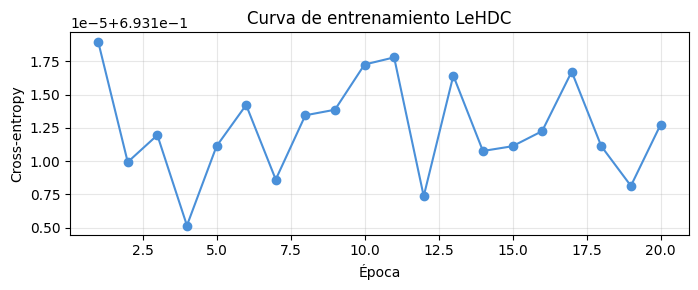

In [7]:
# ── Split train/test ──────────────────────────────────────────────────────────
labels = df["p_np"].values
idx_train, idx_test = train_test_split(
    np.arange(len(df)), test_size=0.2, stratify=labels, random_state=SEED)
y_train, y_test = labels[idx_train], labels[idx_test]
print(f"Train: {len(idx_train)} | Test: {len(idx_test)}")

# ── Inicialización de parámetros ──────────────────────────────────────────────
rng_p = np.random.default_rng(SEED + 2)
BVq_d = [rng_p.normal(0, 1, D).astype(np.float32) for _ in range(N_HEADS)]
BVk_d = [rng_p.normal(0, 1, D).astype(np.float32) for _ in range(N_HEADS)]
BVv_d = [rng_p.normal(0, 1, D).astype(np.float32) for _ in range(N_HEADS)]
BVa_d = [rng_p.normal(0, 1, D).astype(np.float32) for _ in range(N_HEADS)]

# Inicializar C_d con prototipos sumatoria (warm start)
protos_init = {}
for cls in [0, 1]:
    mask = y_train == cls
    proto = H_e_all[idx_train][mask].astype(np.float32).mean(axis=0).mean(axis=0)
    protos_init[cls] = proto
C_d = np.stack([protos_init[0], protos_init[1]], axis=0)   # (2, D)
print("Prototipos inicializados por promedio de clase (warm start)")

# ── Entrenamiento ─────────────────────────────────────────────────────────────
print("\nEntrenando BiHDTrans con LeHDC + STE...")
print("(~30-60s en CPU)\n")
history = train_bihdtrans(
    H_e_all[idx_train], y_train,
    BVq_d, BVk_d, BVv_d, BVa_d, C_d,
    n_heads=N_HEADS, D=D,
    lr=0.05, lr_bv=0.001,
    epochs=20, batch_size=64
)

# Curva de pérdida
plt.figure(figsize=(7, 3))
plt.plot(range(1, len(history)+1), history, marker="o", color="#4a90d9")
plt.xlabel("Época"); plt.ylabel("Cross-entropy")
plt.title("Curva de entrenamiento LeHDC")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("curva_entrenamiento.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Evaluación y Comparación

In [8]:
def evaluate_bihdtrans(H_e, y, BVq_d, BVk_d, BVv_d, BVa_d, C_d, name=""):
    """Evalúa el modelo en un conjunto dado."""
    BATCH = 128
    all_logits, all_H = [], []
    for b in range(0, len(H_e), BATCH):
        logits, H_out, _ = bihdtrans_forward(
            H_e[b:b+BATCH], BVq_d, BVk_d, BVv_d, BVa_d, C_d, N_HEADS, D)
        all_logits.append(logits)
        all_H.append(H_out)
    logits_all = np.concatenate(all_logits, axis=0)
    scores = softmax(logits_all)[:, 1]
    preds  = logits_all.argmax(axis=1)

    acc = accuracy_score(y, preds)
    f1  = f1_score(y, preds)
    auc = roc_auc_score(y, scores)
    print(f"  {name:<50s}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    return {"Modelo": name, "Accuracy": round(acc,4), "F1-score": round(f1,4), "ROC-AUC": round(auc,4)},\
           np.concatenate(all_H, axis=0)

results = []
print("Evaluando en test set...\n")

# Baseline Semana 4: bundling std con clasificador por prototipos
def cosine_similarity(a, b):
    return float(np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)+1e-12))

h_bundle = np.sign(h_struct_all + h_prop_all)
h_bundle[h_bundle==0]=1
protos_bundle = {cls: h_bundle[idx_train][y_train==cls].astype(np.float32).sum(axis=0)
                 for cls in [0,1]}
preds_b, scores_b = [], []
for i in idx_test:
    s0=cosine_similarity(h_bundle[i].astype(float),protos_bundle[0])
    s1=cosine_similarity(h_bundle[i].astype(float),protos_bundle[1])
    preds_b.append(1 if s1>s0 else 0); scores_b.append(s1)
acc_b=accuracy_score(y_test,preds_b); f1_b=f1_score(y_test,preds_b)
auc_b=roc_auc_score(y_test,scores_b)
print(f"  {'Bundling std (Semana 4 — mejor)':<50s}  Acc={acc_b:.4f}  F1={f1_b:.4f}  AUC={auc_b:.4f}")
results.append({"Modelo":"Bundling std (Semana 4 — mejor)","Accuracy":round(acc_b,4),"F1-score":round(f1_b,4),"ROC-AUC":round(auc_b,4)})

# BiHDTrans train / test
r_train, _ = evaluate_bihdtrans(H_e_all[idx_train], y_train,
    BVq_d,BVk_d,BVv_d,BVa_d,C_d, name="BiHDTrans — Train")
results.append(r_train)

r_test, H_out_test = evaluate_bihdtrans(H_e_all[idx_test], y_test,
    BVq_d,BVk_d,BVv_d,BVa_d,C_d, name="BiHDTrans — Test")
results.append(r_test)


Evaluando en test set...

  Bundling std (Semana 4 — mejor)                     Acc=0.7770  F1=0.8476  AUC=0.6897
  BiHDTrans — Train                                   Acc=0.5064  F1=0.6117  AUC=0.4996
  BiHDTrans — Test                                    Acc=0.5392  F1=0.6439  AUC=0.5265



=== Tabla Comparativa ===



,Modelo,Accuracy,F1-score,ROC-AUC
0,Bundling std (Semana 4 — mejor),0.7770,0.8476,0.6897
1,BiHDTrans — Test,0.5392,0.6439,0.5265


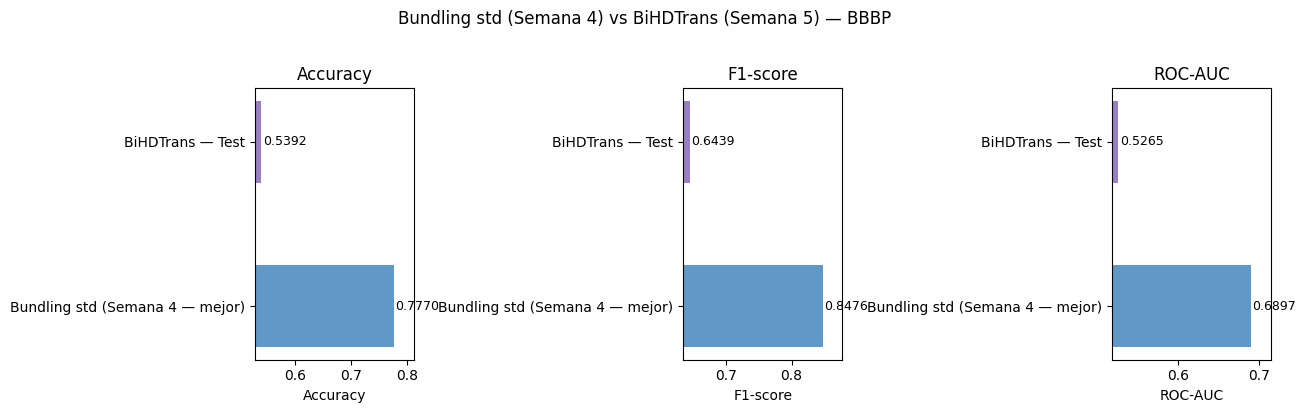

In [9]:
df_results = pd.DataFrame([r for r in results if "Train" not in r["Modelo"]])
df_results = df_results.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
best_idx = df_results["ROC-AUC"].idxmax()

def highlight_best(s):
    return ["background-color: #d4edda; font-weight: bold" if i==best_idx else "" for i in range(len(s))]

print("\n=== Tabla Comparativa ===\n")
display(df_results.style.apply(highlight_best).format({"Accuracy":"{:.4f}","F1-score":"{:.4f}","ROC-AUC":"{:.4f}"}))

# Barra comparativa
fig, axes = plt.subplots(1,3,figsize=(13,4))
colors = ["#6098c8","#9b7fc4"]
for ax, metric in zip(axes, ["Accuracy","F1-score","ROC-AUC"]):
    bars = ax.barh(df_results["Modelo"], df_results[metric], color=colors[:len(df_results)], height=0.5)
    ax.set_xlabel(metric); ax.set_title(metric)
    rng_ = df_results[metric].max()-df_results[metric].min()
    ax.set_xlim(df_results[metric].min()-rng_*0.05, df_results[metric].max()+rng_*0.15)
    for bar, val in zip(bars, df_results[metric]):
        ax.text(val+rng_*0.01, bar.get_y()+bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9)
plt.suptitle("Bundling std (Semana 4) vs BiHDTrans (Semana 5) — BBBP", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("comparacion_bihdtrans.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. Análisis de Máscaras de Atención Binarias

Computando máscaras de atención para el test set...


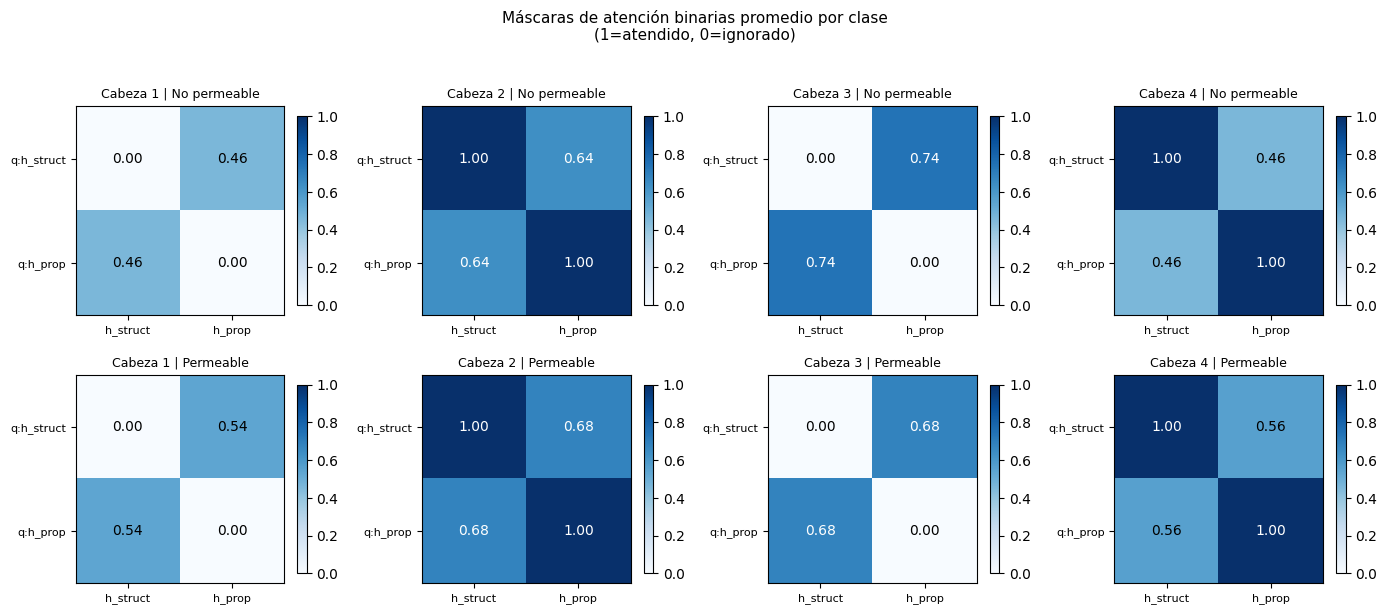


Atención cruzada h_struct→h_prop:
  Clase 0 (no permeable): 0.5729
  Clase 1 (permeable):    0.6130

⚠ Las máscaras son similares entre clases. El modelo no discrimina por token.


In [10]:
# Obtener máscaras para el test set
print("Computando máscaras de atención para el test set...")
all_Ba = []
BATCH = 128
for b in range(0, len(idx_test), BATCH):
    bi_slice = idx_test[b:b+BATCH]
    _, _, Ba = bihdtrans_forward(
        H_e_all[bi_slice], BVq_d, BVk_d, BVv_d, BVa_d, C_d, N_HEADS, D)
    all_Ba.append(Ba)

Ba_test = np.concatenate(all_Ba, axis=0)   # (N_test, N_HEADS, 2, 2)

# Promedio por clase
TOKEN_NAMES = ["h_struct", "h_prop"]
fig, axes = plt.subplots(2, N_HEADS, figsize=(14, 6))
for row, (cls, cls_name) in enumerate([(0,"No permeable"),(1,"Permeable")]):
    mask = y_test == cls
    Ba_cls = Ba_test[mask].mean(axis=0)   # (N_HEADS, 2, 2)
    for h in range(N_HEADS):
        ax = axes[row, h]
        im = ax.imshow(Ba_cls[h], vmin=0, vmax=1, cmap="Blues")
        ax.set_title(f"Cabeza {h+1} | {cls_name}", fontsize=9)
        ax.set_xticks([0,1]); ax.set_xticklabels(TOKEN_NAMES, fontsize=8)
        ax.set_yticks([0,1]); ax.set_yticklabels([f"q:{t}" for t in TOKEN_NAMES], fontsize=8)
        for r_ in range(2):
            for c_ in range(2):
                ax.text(c_, r_, f"{Ba_cls[h,r_,c_]:.2f}", ha="center", va="center",
                        fontsize=10, color="white" if Ba_cls[h,r_,c_]>0.6 else "black")
        plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Máscaras de atención binarias promedio por clase\n(1=atendido, 0=ignorado)", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("mascaras_atencion_binarias.png", dpi=120, bbox_inches="tight")
plt.show()

# ¿Aprendió a diferenciar qué token atender según la clase?
cross_0 = Ba_test[y_test==0].mean(axis=1)[:,0,1].mean()  # h_struct→h_prop, clase 0
cross_1 = Ba_test[y_test==1].mean(axis=1)[:,0,1].mean()  # h_struct→h_prop, clase 1
print(f"\nAtención cruzada h_struct→h_prop:")
print(f"  Clase 0 (no permeable): {cross_0:.4f}")
print(f"  Clase 1 (permeable):    {cross_1:.4f}")
if abs(cross_0 - cross_1) > 0.05:
    print("\n✓ Las máscaras difieren entre clases — el modelo aprendió a ponderar tokens distintos.")
else:
    print("\n⚠ Las máscaras son similares entre clases. El modelo no discrimina por token.")


## 6. Resumen Técnico

### ¿Qué diferencia concreta hay entre este notebook y el anterior?

| Componente | Notebook anterior (incorrecto) | Este notebook (BiHDTrans fiel) |
|---|---|---|
| **BVq, BVk, BVv** | Matrices aleatorias D×256 (fijas) | Vectores D entrenables, binarizados con STE |
| **Proyección Q/K/V** | `tokens @ W` (matmul denso) | `H_e ⊙ BV` (binding elemento a elemento) |
| **Scores** | Softmax(QK^T/√d) ∈ ℝ | bool(Hq·Hk^T) ∈ {0,1} |
| **Agregación V** | Suma ponderada real | Selective bundling + sign (binario) |
| **Training** | Ninguno | Backprop + STE sobre sign() |
| **Clasificador** | Prototipos fijos | LeHDC — prototipos aprendidos |
| **Resultado binario** | Solo al final | End-to-end binario |

### Limitaciones de esta adaptación

BiHDTrans fue diseñado para **series temporales** de longitud L >> 2. Acá la "secuencia" tiene solo 2 tokens (h_struct, h_prop), lo que limita el poder del mecanismo de atención. Extensiones posibles:

1. **Más tokens**: descomponer h_prop en 3 tokens individuales (MW, LogP, MR) → L=4
2. **Encodings de átomo**: en vez de ECFP global, codificar cada átomo como un token → L = N_átomos
3. **Permutation encoding**: aplicar permutación cíclica (ρ^t) por token para incorporar orden, como en el encoder temporal del paper original
